In [16]:
# Cell 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules for modeling and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Set visualization style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [19]:
# Cell 2: Load the dataset
# Ensure the CSV file is in the same directory as this notebook
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Display the first 5 rows
display(df.head())

# Check for missing values and data types
print("\n--- Dataset Info ---")
df.info()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  147

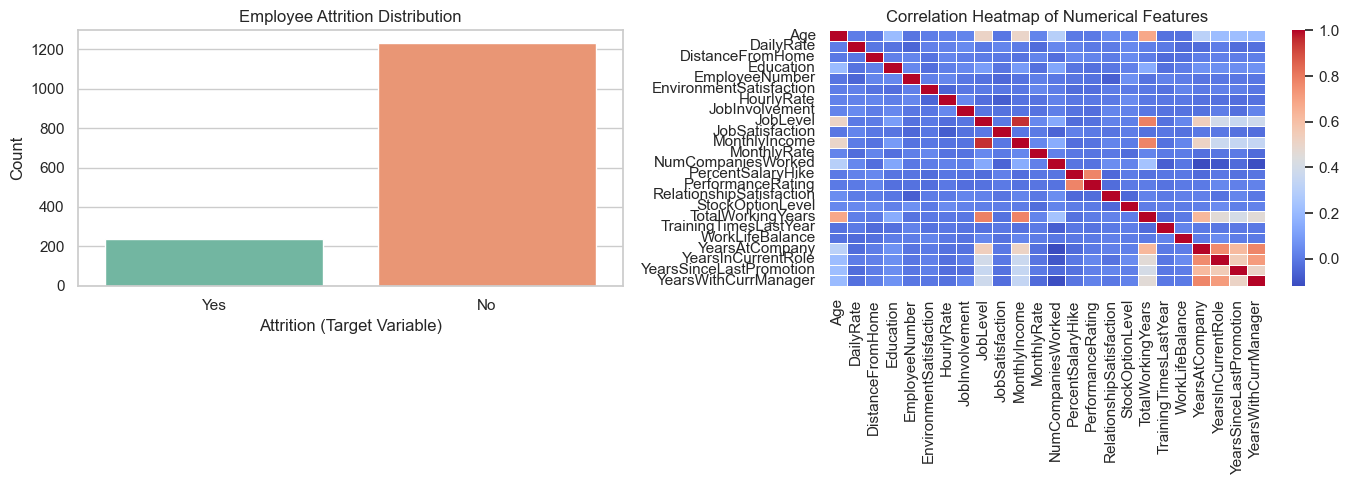

In [20]:
# Cell 3: Exploratory Data Analysis
plt.figure(figsize=(14, 5))

# Plot 1: Attrition Count
plt.subplot(1, 2, 1)
sns.countplot(x='Attrition', data=df, palette='Set2')
plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition (Target Variable)')
plt.ylabel('Count')

# Plot 2: Correlation Heatmap of numerical features
plt.subplot(1, 2, 2)
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
# Drop columns that have zero variance (same value for all rows)
cols_to_drop = ['EmployeeCount', 'StandardHours']
numerical_cols = [col for col in numerical_cols if col not in cols_to_drop]

corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')

plt.tight_layout()
plt.show()

In [21]:
# Cell 4: Data Preprocessing

# 1. Drop columns that offer no predictive value (zero variance or identifiers)
df = df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'])

# 2. Encode the Target Variable (Attrition: Yes=1, No=0)
le = LabelEncoder()
df['Attrition'] = le.fit_transform(df['Attrition'])

# 3. One-Hot Encode remaining categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# 4. Define Features (X) and Target (y)
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# 5. Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (1176, 44)
Testing data shape: (294, 44)


In [22]:
# Cell 5: Model Training

# Initialize the models
log_reg = LogisticRegression(random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the models
log_reg.fit(X_train_scaled, y_train)
rf_clf.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_rf = rf_clf.predict(X_test_scaled)

print("Models trained successfully!")

Models trained successfully!


--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



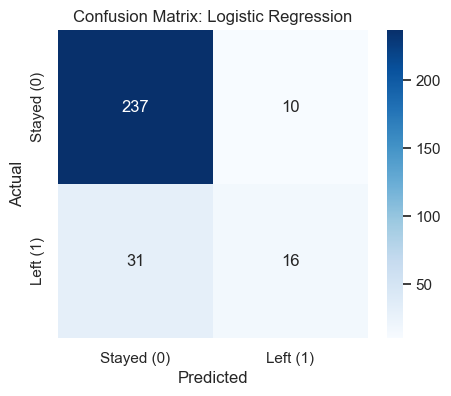

--- Random Forest Classifier Performance ---
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294



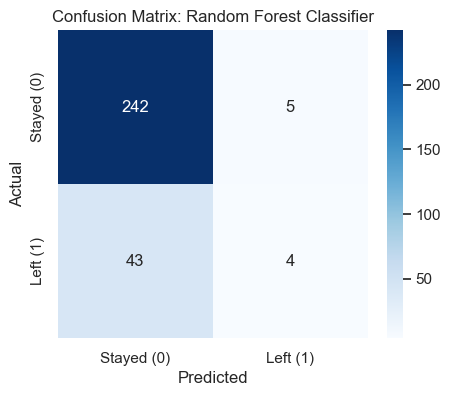

In [23]:
# Cell 6: Model Evaluation

def evaluate_model(y_true, y_pred, model_name):
    print(f"--- {model_name} Performance ---")
    print(classification_report(y_true, y_pred))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Stayed (0)', 'Left (1)'], 
                yticklabels=['Stayed (0)', 'Left (1)'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Evaluate Logistic Regression
evaluate_model(y_test, y_pred_log, "Logistic Regression")

# Evaluate Random Forest
evaluate_model(y_test, y_pred_rf, "Random Forest Classifier")

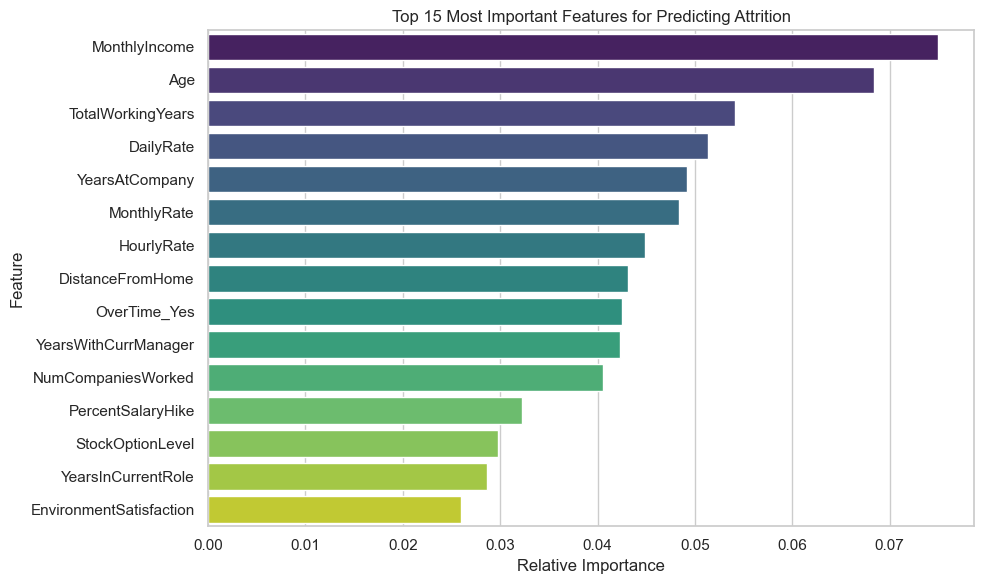

In [24]:
# Cell 7: Feature Importance Analysis (Random Forest)

# Extract feature importances from the Random Forest model
importances = rf_clf.feature_importances_
feature_names = X.columns

# Create a DataFrame for easier plotting
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False).head(15) # Top 15 features

# Plot the Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title('Top 15 Most Important Features for Predicting Attrition')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()